Epoch: 0 MSE: 799.4111507700006
Epoch: 50 MSE: 22.793074358802404
Epoch: 100 MSE: 22.791515815812403
Epoch: 150 MSE: 22.79055802074609
Epoch: 200 MSE: 22.789969412414504
Epoch: 250 MSE: 22.78960768600748

Final Results
Slope (m): 5.695725667149117
Intercept (b): 1.1862977064575704
Final MSE: 22.789385388791267


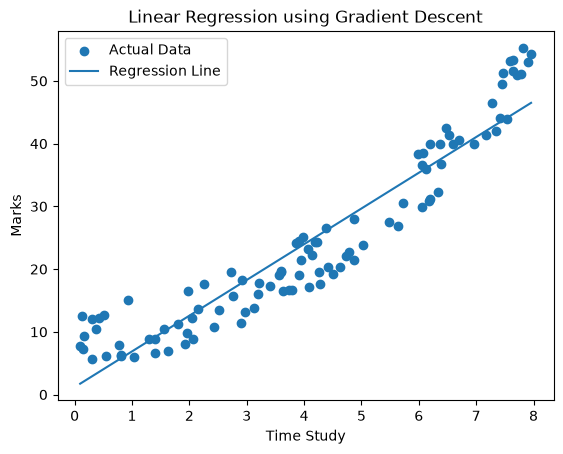

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Student_Marks.csv")

X = df["time_study"]
Y = df["Marks"]

m = 0
b = 0

learning_rate = 0.01
epochs = 300

n = len(X)

for epoch in range(epochs):

    dm = 0
    db = 0
    total_error = 0

    for i in range(n):

        x = X.iloc[i]
        y = Y.iloc[i]

        y_pred = m * x + b

        error = y - y_pred

        total_error += error ** 2

        dm += -2 * error * x
        db += -2 * error

    dm = dm / n
    db = db / n

    mse = total_error / n

    m = m - learning_rate * dm
    b = b - learning_rate * db

    if epoch % 50 == 0:
        print("Epoch:", epoch, "MSE:", mse)

df["Predicted_Marks"] = m * X + b

error = Y - df["Predicted_Marks"]
mse = (error ** 2).mean()

print("\nFinal Results")
print("Slope (m):", m)
print("Intercept (b):", b)
print("Final MSE:", mse)

plt.scatter(X, Y, label="Actual Data")

sorted_data = df.sort_values("time_study")

plt.plot(
    sorted_data["time_study"],
    sorted_data["Predicted_Marks"],
    label="Regression Line"
)

plt.xlabel("Time Study")
plt.ylabel("Marks")
plt.title("Linear Regression using Gradient Descent")
plt.legend()
plt.show()